# PCA Risk Factor Models

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / 'unsupervised_utils.py').exists():
        sys.path.insert(0, str(parent))
        break

from unsupervised_utils import *

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
returns = make_asset_returns(seed=134)
factors, loadings = risk_factor_pca(returns)
factors.to_parquet(OUTPUT / 'pca_risk_factors.parquet')
loadings.to_csv(OUTPUT / 'pca_factor_loadings.csv')
factors.head()

,factor_1,factor_2,factor_3,factor_4,factor_5
2023-06-16,3.7959,-1.3297,-1.4176,0.5993,-0.1458
2023-06-19,-1.8524,-2.4319,2.3732,-0.5081,0.7467
2023-06-20,-0.5505,-0.0823,1.1699,0.1189,-0.2279
2023-06-21,2.0440,-4.9075,2.5429,1.2942,0.1570
2023-06-22,-5.7057,1.5664,-0.1158,0.0065,-0.1493


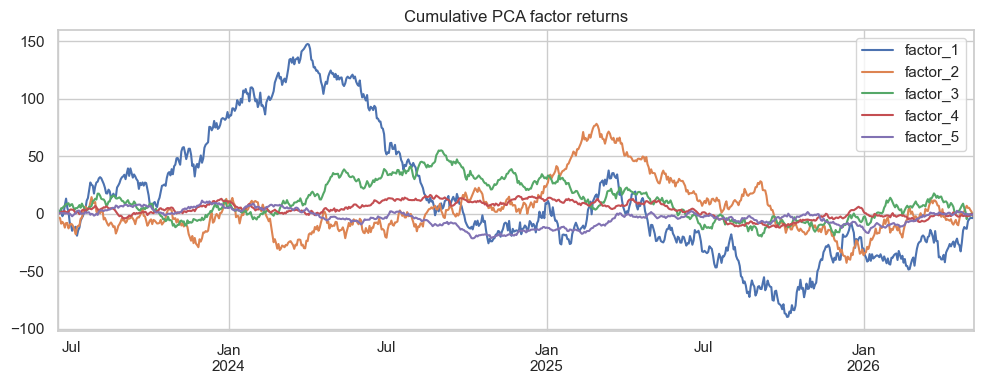

In [3]:
factors.cumsum().plot(figsize=(10, 4), title='Cumulative PCA factor returns')
plt.tight_layout()